## Задача 2. Реализация подсчёта треугольников

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
import graphblas as gb

gb.init("suitesparse", blocking=False)

from graphblas import Matrix, dtypes, monoid, agg
from graphblas.io import mmread

In [ ]:
def naive_cube(A: Matrix) -> int:
    A3 = A.mxm(A.mxm(A))
    return int(A3.diag().reduce(agg.sum).value or 0) / 6


def naive_mask(A):
    A2 = A.mxm(A)
    mask = A.dup(dtype=dtypes.BOOL)
    result = A2.dup(mask=mask)
    return int(result.reduce_scalar(monoid.plus).value or 0) / 6


def cohen(A):
    L = gb.select.tril(A)
    U = gb.select.triu(A)
    mask = A.dup(dtype=dtypes.BOOL)
    result = L.mxm(U).dup(mask=mask)
    return int(result.reduce_scalar(monoid.plus).value or 0) / 2


def sandia(A: Matrix) -> int:
    U = gb.select.triu(A)
    mask = U.dup(dtype=dtypes.BOOL)
    result = U.mxm(U).dup(mask=mask)
    return int(result.reduce_scalar(monoid.plus).value or 0)


def vertex_triangles(A: Matrix) -> np.ndarray:
    A2 = A.mxm(A)
    mask = A.dup(dtype=dtypes.BOOL)
    C = A2.dup(mask=mask)
    row_sums = C.reduce_rowwise(monoid.plus)
    
    arr = row_sums.to_dense(fill_value=0) // 2
    return arr.astype(np.int64)

In [ ]:
def run_tests():
    # Треугольник из трёх вершин
    rows = [0, 1, 2, 1, 2, 0]   # рёбра 0-1, 1-2, 2-0
    cols = [1, 2, 0, 0, 1, 2]
    vals = np.ones(6)
    tri = Matrix.from_coo(rows, cols, vals, nrows=3, ncols=3, dtype=dtypes.FP64)
    assert naive_cube(tri) == 1
    assert naive_mask(tri) == 1
    assert cohen(tri) == 1
    assert sandia(tri) == 1
    assert (vertex_triangles(tri) == [1, 1, 1]).all()

    # Граф-квадрат (цикл из 4 вершин) — нет треугольников
    rows = [0,1,1,2,2,3,3,0]
    cols = [1,0,2,1,3,2,0,3]
    data = np.ones(8)
    A_square = Matrix.from_coo(rows, cols, data, nrows=4, ncols=4, dtype=dtypes.FP64)
    assert naive_cube(A_square) == 0
    assert naive_mask(A_square) == 0
    assert cohen(A_square) == 0
    assert sandia(A_square) == 0
    np.testing.assert_array_equal(vertex_triangles(A_square), [0,0,0,0])

    # Полносвязный граф K4 — 4 треугольника
    rows = []
    cols = []
    for i in range(4):
        for j in range(i+1, 4):
            rows.extend([i, j])
            cols.extend([j, i])
    data = np.ones(12)
    A_k4 = Matrix.from_coo(rows, cols, data, nrows=4, ncols=4, dtype=dtypes.FP64)
    assert naive_cube(A_k4) == 4
    assert naive_mask(A_k4) == 4
    assert cohen(A_k4) == 4
    assert sandia(A_k4) == 4
    np.testing.assert_array_equal(vertex_triangles(A_k4), [3,3,3,3])

    print("Все тесты пройдены успешно.")

run_tests()

Все тесты пройдены успешно.


---

In [6]:
def test(A):
    result = [naive_cube(A), naive_mask(A), cohen(A), sandia(A)]
    print(result)
    if not all(element == result[0] for element in result):
       print("All return values are not equal")
    
    %timeit naive_cube(A)
    %timeit naive_mask(A)
    %timeit cohen(A)
    %timeit sandia(A)

In [24]:
files = [
    '../data/USpowerGrid/USpowerGrid.mtx',
    # '../data/auto/auto.mtx',
    # -----
    '../data/wing/wing.mtx',
    '../data/minnesota/minnesota.mtx',
    '../data/G2/G2.mtx',
    '../data/dolphins/dolphins.mtx',
    '../data/Erdos981/Erdos981.mtx',
    '../data/karate/karate.mtx',
]

In [25]:
for f_path in files:
    M = mmread(f_path)
    test(M)

[651.0, 651.0, 651.0, 651]
11.8 ms ± 360 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2 ms ± 69.5 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.02 ms ± 186 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.9 ms ± 125 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
[6685.0, 6685.0, 6685.0, 6685]
70.7 ms ± 4.29 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
15.1 ms ± 733 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
18.6 ms ± 874 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
14.7 ms ± 399 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
[53.0, 53.0, 53.0, 53]
3.45 ms ± 213 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
924 µs ± 89.8 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.3 ms ± 110 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.04 ms ± 73.3 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
[18194.0, 18194.0, 18194.0, 18194]
154 ms ± 4.62 ms per loop

---

In [ ]:
def generate_random_graph(n: int, p: float, seed: int = None) -> Matrix:
    """
    Генерация случайного неориентированного графа с n вершинами.
    Вероятность ребра p.
    Возвращает симметричную матрицу смежности типа FP64 с единицами на местах рёбер.
    
    Parameters
    ----------
    n : int
        Количество вершин.
    p : float
        Вероятность наличия ребра между любыми двумя различными вершинами.
    seed : int, optional
        Сид для генератора случайных чисел.
    
    Returns
    -------
    graphblas.Matrix
        Симметричная матрица смежности.
    """
    rng = np.random.default_rng(seed)
    
    iu = np.triu_indices(n, k=1)
    edges = rng.random(len(iu[0])) < p
    
    rows = iu[0][edges]
    cols = iu[1][edges]
    
    all_rows = np.concatenate([rows, cols])
    all_cols = np.concatenate([cols, rows])
    vals = np.ones(2 * len(rows), dtype=np.float64)
    
    return Matrix.from_coo(all_rows, all_cols, vals, nrows=n, ncols=n, dtype=dtypes.FP64)

In [55]:
sizes = [100, 500, 1_000, 2_000, 5_000, 10_000]
probs = [0.001, 0.005, 0.01, 0.05]
seed = 42

In [56]:
num_runs = 5

methods = [
    ("naive_cube", naive_cube),
    ("naive_mask", naive_mask),
    ("cohen", cohen),
    ("sandia", sandia)
]

records = []
for n in sizes:
    for p in probs:
        current_seed = seed + n * 1000 + int(p * 1000) * 10
        A = generate_random_graph(n, p, seed=current_seed)

        result = [naive_cube(A), naive_mask(A), cohen(A), sandia(A)]
        if not all(element == result[0] for element in result):
            print("All return values are not equal")
            continue
        
        print(f"Benchmark: n={n}, p={p}")
        print(result)
        for name, func in methods:
            times = []
            for _ in range(num_runs):
                start = time.perf_counter()
                _ = func(A)
                end = time.perf_counter()
                times.append(end - start)
            avg_time = np.mean(times)
            std_time = np.std(times)
            records.append({
                'n': n,
                'p': p,
                'method': name,
                'time_sec': avg_time,
                'std_sec': std_time
            })
            print(f"  {name}: {avg_time:.6f} +- {std_time:.6f} s")

Benchmark: n=100, p=0.001
[0.0, 0.0, 0.0, 0]
  naive_cube: 0.001254 +- 0.000186 s
  naive_mask: 0.000869 +- 0.000196 s
  cohen: 0.000685 +- 0.000429 s
  sandia: 0.000469 +- 0.000155 s
Benchmark: n=100, p=0.005
[0.0, 0.0, 0.0, 0]
  naive_cube: 0.000497 +- 0.000057 s
  naive_mask: 0.000454 +- 0.000250 s
  cohen: 0.000641 +- 0.000077 s
  sandia: 0.000452 +- 0.000036 s
Benchmark: n=100, p=0.01
[0.0, 0.0, 0.0, 0]
  naive_cube: 0.000615 +- 0.000299 s
  naive_mask: 0.000248 +- 0.000028 s
  cohen: 0.000479 +- 0.000071 s
  sandia: 0.000358 +- 0.000060 s
Benchmark: n=100, p=0.05
[15.0, 15.0, 15.0, 15]
  naive_cube: 0.001341 +- 0.000169 s
  naive_mask: 0.000409 +- 0.000105 s
  cohen: 0.000776 +- 0.000314 s
  sandia: 0.000375 +- 0.000129 s
Benchmark: n=500, p=0.001
[0.0, 0.0, 0.0, 0]
  naive_cube: 0.000275 +- 0.000030 s
  naive_mask: 0.000165 +- 0.000024 s
  cohen: 0.000285 +- 0.000023 s
  sandia: 0.000196 +- 0.000014 s
Benchmark: n=500, p=0.005
[2.0, 2.0, 2.0, 2]
  naive_cube: 0.000899 +- 0.00006

In [57]:
df = pd.DataFrame(records)
df.head()

,n,p,method,time_sec,std_sec
0,100,0.001,naive_cube,0.001254,0.000186
1,100,0.001,naive_mask,0.000869,0.000196
2,100,0.001,cohen,0.000685,0.000429
3,100,0.001,sandia,0.000469,0.000155
4,100,0.005,naive_cube,0.000497,0.000057


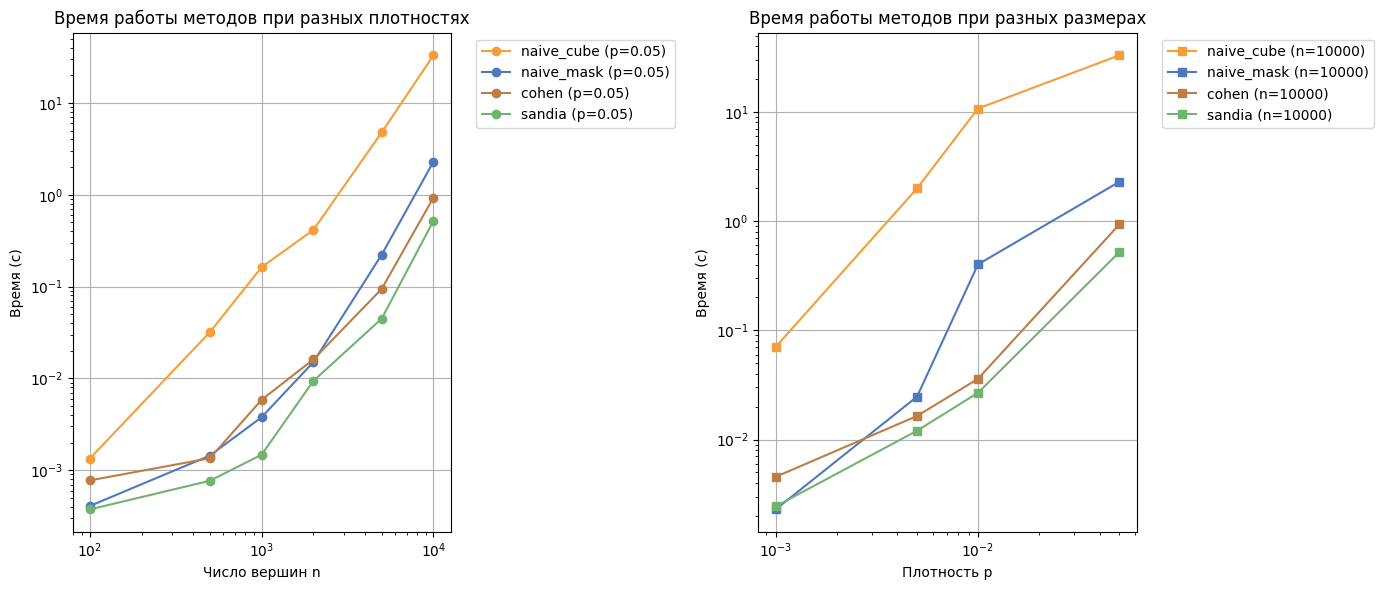

In [58]:
plt.figure(figsize=(14, 6))

colors = {
    'naive_cube': ['#8c2d04', '#b33e0a', '#d95f0e', '#ed7f1b', '#f79d3a', '#fbb45c', '#fcca7d', '#fee0a2', '#feedcc', '#fff7ec'],  # Оранжевая гамма
    'naive_mask': ['#0c2c50', '#1c3d6b', '#2c5087', '#3d64a3', '#4f79bf', '#6790d1', '#81a8dd', '#a2c0e8', '#c3d8f2', '#e6f0ff'],  # Синяя гамма
    'cohen': ['#4d2e1b', '#683f24', '#85522e', '#a26739', '#be7d45', '#d39558', '#e3ae73', '#f0c891', '#f8e0b5', '#fff3e0'],  # Коричневая гамма
    'sandia': ['#2e4e2e', '#3d663d', '#4d804d', '#5e9a5e', '#70b470', '#88c488', '#a2d6a2', '#bde6bd', '#d9f2d9', '#f0fff0']   # Зелёная гамма
}

plt.subplot(1, 2, 1)
for method, _ in methods:
    i, p = 4, 0.05
    # for i, p in enumerate(probs):
    subset = df[df['p'] == p]
    data = subset[subset['method'] == method]
    plt.loglog(data['n'], data['time_sec'], c=colors[method][i], marker='o', label=f'{method} (p={p})')
plt.xlabel('Число вершин n')
plt.ylabel('Время (с)')
plt.title('Время работы методов при разных плотностях')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
for method, _ in methods:
    i, n = 4, 10_000
    # for i, n in enumerate(sizes):
    subset = df[df['n'] == n]
    data = subset[subset['method'] == method]
    plt.loglog(data['p'], data['time_sec'], c=colors[method][i], marker='s', label=f'{method} (n={n})')
plt.xlabel('Плотность p')
plt.ylabel('Время (с)')
plt.title('Время работы методов при разных размерах')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

---

Как можно увидеть:

- В большинстве случаев алгоритм Сандии справляется лучше всех остальных, тогда как наивное вычисление \(M^3\) работает медленнее всех.
- Для маленьких матриц с маленькой плотностью: size и p порядков 100 и 0.01 соовтетвенно (то есть рёбер в данном случае единицы), - наивный алгоритм с маской имеет небольшое преимущество - проще умножить несколько значений, чем сначала разложить и потом умножить.

Данные результаты ожидаемы. Стоит также заметить, что при увеличении размера матрицы и плотности, время выполнения для всех алгоритмов приближается к \(M^3\). 

Однако, в среднем, используются матрицы среднего размера и достаточно разреженные, поэтому использование рассмотренных оптимизаций является очень даже оправданным и полезным.